In [1]:
# Iris 데이터셋 기반 통계분석 종합 실습
# 분석 목차:
#   1. 데이터 로딩 및 탐색
#   2. 상관분석 (Correlation Analysis)
#   3. t-test (독립표본 t검정)
#   4. ANOVA (일원분산분석)
#   5. PCA (주성분분석)
#   6. 군집분석 (K-Means Clustering)
#   7. 군집 프로파일링 (Cluster Profiling)

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from scipy import stats

In [5]:
# 한글깨짐 해결, 원인:디폴트 영문글꼴==>한글글꼴
import matplotlib.pyplot as plt
import platform
if platform.system() == 'Windows': # W:대문자
    plt.rcParams['font.family'] = 'Malgun Gothic' # M,G:대문자, 중간에 스페이스 한칸
elif platform.system() == 'Darwin': # 맥OS, D:대문자
    plt.rcParams['font.family'] = 'AppleGothic'
else: # 리눅스
    plt.rcParams['font.family'] = 'NanumGothic'
# -(마이너스 기호) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [6]:
from sklearn.datasets import load_iris

In [7]:
iris = load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [8]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['y'] = iris.target
df['species'] = df['y'].map( {0:'setosa',1:'versicolor',2:'virginica'} )
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),y,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


In [9]:
# 꽃받침_길이, 꽃받침_너비, 꽃잎_길이, 꽃잎_너비, 품종(y:0,1,2), 품종명
df.columns = [ 'sepal_length', 'sepal_width', 'petal_length', 'petal_width',
              'y', 'species' ]
df

,sepal_length,sepal_width,petal_length,petal_width,y,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   y             150 non-null    int64  
 5   species       150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [11]:
df.describe().round(2)

,sepal_length,sepal_width,petal_length,petal_width,y
count,150.00,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20,1.00
std,0.83,0.44,1.77,0.76,0.82
min,4.30,2.00,1.00,0.10,0.00
25%,5.10,2.80,1.60,0.30,0.00
50%,5.80,3.00,4.35,1.30,1.00
75%,6.40,3.30,5.10,1.80,2.00
max,7.90,4.40,6.90,2.50,2.00


In [12]:
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [13]:
numeric_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

In [14]:
df.groupby('species')[numeric_cols].mean().round(2)

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.01,3.43,1.46,0.25
versicolor,5.94,2.77,4.26,1.33
virginica,6.59,2.97,5.55,2.03


## 상관분석 (Correlation Analysis)
- 연속형 변수 간의 선형 관계를 파악
- 피어슨 상관계수: -1 ~ +1
- 예를 들어, "공부 시간이 늘어날 때 성적도 직선 모양으로 쭉 올라가는가?"를 측정하는 것.

In [15]:
corr_matrix = df[ numeric_cols ].corr().round(3)
corr_matrix

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000,-0.118,0.872,0.818
sepal_width,-0.118,1.000,-0.428,-0.366
petal_length,0.872,-0.428,1.000,0.963
petal_width,0.818,-0.366,0.963,1.000


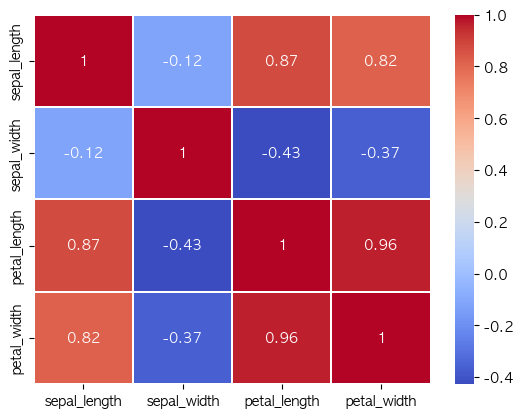

In [16]:
sns.heatmap(corr_matrix, annot=True, linewidths=0.1, cmap=plt.cm.coolwarm)
plt.show()

In [17]:
r, p_value = stats.pearsonr( df['petal_length'], df['petal_width'] )
print(f"상관계수(r) = {r:.4f}")
print(f"p-value = {p_value:.2e}")
print(f"해석: {'차이가 있다(0.05 미만 ==> 대립가설 채택)' if p_value < 0.05 else '차이가 없다'}")

상관계수(r) = 0.9629
p-value = 4.68e-86
해석: 차이가 있다(0.05 미만 ==> 대립가설 채택)


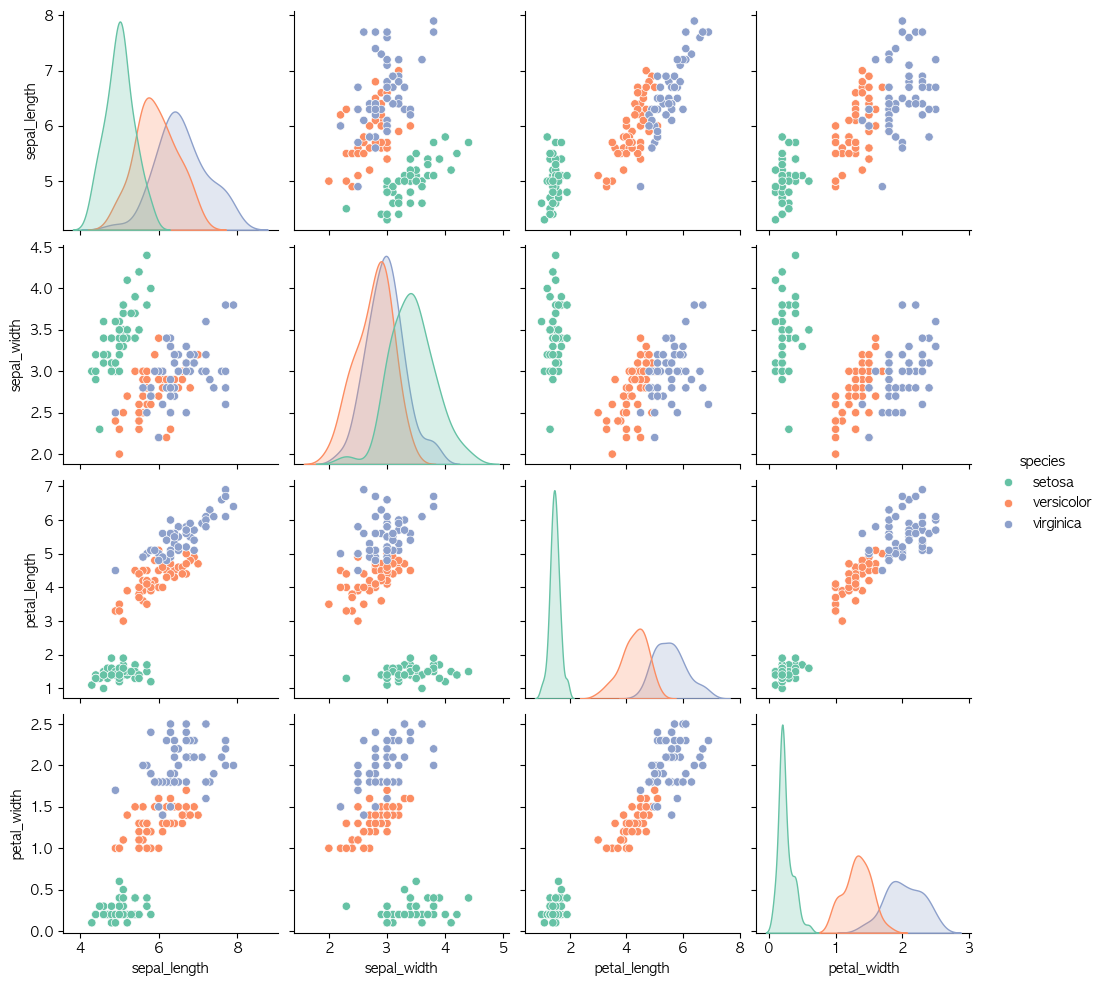

In [18]:
sns.pairplot(df, vars=numeric_cols, hue='species', palette='Set2')
plt.show() # 그래프 해석 : 차이가 있다. 각 품종 별로 각각의 영역이 떨어져 있음.

## t-test (독립표본 t검정)
- 두 그룹의 평균 차이가 통계적으로 유의미한지 검정
- 여기서는 setosa vs versicolor 비교

In [19]:
setosa = df[ df['species'] == 'setosa' ]
versicolor = df[ df['species'] == 'versicolor' ]

In [20]:
setosa.shape, versicolor.shape

((50, 6), (50, 6))

In [21]:
for col in numeric_cols:
    print(col, stats.ttest_ind(setosa[col], versicolor[col]))
# 해석 : 모든 컬럼의 pvalue가 0.05 보다 작기 때문에 모든 컬럼은 차이가 있다.(대립가설 채택)

sepal_length TtestResult(statistic=np.float64(-10.52098626754911), pvalue=np.float64(8.985235037487079e-18), df=np.float64(98.0))
sepal_width TtestResult(statistic=np.float64(9.454975848128596), pvalue=np.float64(1.8452599454769255e-15), df=np.float64(98.0))
petal_length TtestResult(statistic=np.float64(-39.492719391538095), pvalue=np.float64(5.404910513441832e-62), df=np.float64(98.0))
petal_width TtestResult(statistic=np.float64(-34.08034154357719), pvalue=np.float64(3.831095388248162e-56), df=np.float64(98.0))


In [22]:
# two_species = df[ df['species'].isin( ['setosa', 'versicolor'] ) ]
# two_species = df.query("species in ['setosa', 'versicolor']")
two_species = df[(df['species'] == 'setosa') | (df['species'] == 'versicolor')]
two_species.shape

(100, 6)

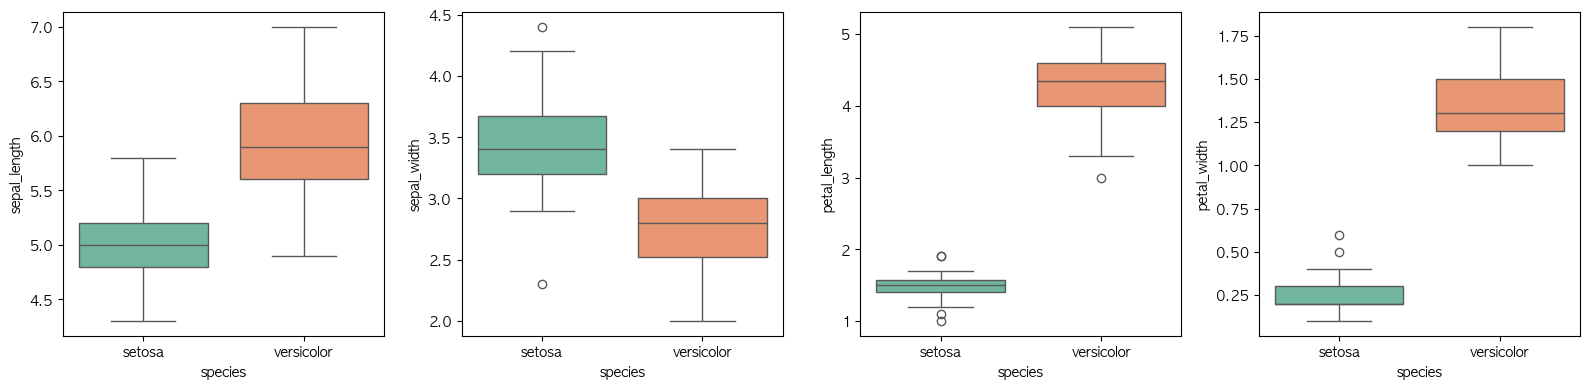

In [23]:
plt.figure(figsize=(16, 4))
for i, col in enumerate( numeric_cols, 1 ): # 1은 1부터 시작
    # print(i, col) # 1 sepal_length, 2 sepal_width, 3 petal_length, 4 petal_width
    plt.subplot(1,4,i) # plt.subplot(1,4,1), plt.subplot(1,4,2), plt.subplot(1,4,3), plt.subplot(1,4,4)
    sns.boxplot(data=two_species, x='species', y=col, palette='Set2')
plt.tight_layout()
plt.show() # 그래프 해석 : 차이가 있다.

## ANOVA (일원분산분석 : One-way ANOVA)
- 3개 이상 그룹의 평균 차이를 검정
- 핵심은 아주 심플. "세 그룹 이상의 평균이 통계적으로 진짜 차이가 있는가?"를 확인하는 도구.
- 일원(One-way): 비교 기준(독립변수)이 딱 하나라는 뜻.
- 분산분석(ANOVA, Analysis of Variance): 평균을 비교하기 위해서 분산(데이터가 퍼진 정도)을 사용하기 때문에 붙은 이름.
- 사후검정 (Tukey HSD)

In [24]:
# groups = [ df[ df['species_name'] == s ] for s in ['setosa','versicolor','virginica'] ]
setosa = df[ df['species'] == 'setosa' ]
versicolor = df[ df['species'] == 'versicolor' ]
virginica = df[ df['species'] == 'virginica' ]

In [25]:
print(df['species'].unique())
print(len(setosa), len(versicolor), len(virginica))

['setosa' 'versicolor' 'virginica']
50 50 50


In [26]:
for col in numeric_cols:
    print( col, stats.f_oneway(setosa[col], versicolor[col], virginica[col]) )
    # f_oneway(setosa['sepal_length'],versicolor['sepal_length'],virginica['sepal_length']
# 해석 : 차이가 있다(0.05 미만 ==> 대립가설 채택)
print("* 귀무가설(H0): 세 그룹의 평균이 동일하다")
print("* p < 0.05이면 최소 하나의 그룹 평균이 다르다고 결론")

sepal_length F_onewayResult(statistic=np.float64(119.26450218450475), pvalue=np.float64(1.6696691907693469e-31))
sepal_width F_onewayResult(statistic=np.float64(49.1600400896121), pvalue=np.float64(4.492017133309054e-17))
petal_length F_onewayResult(statistic=np.float64(1180.1611822529735), pvalue=np.float64(2.856776610962826e-91))
petal_width F_onewayResult(statistic=np.float64(960.007146801811), pvalue=np.float64(4.1694458394425775e-85))
* 귀무가설(H0): 세 그룹의 평균이 동일하다
* p < 0.05이면 최소 하나의 그룹 평균이 다르다고 결론


In [27]:
try:
    import statsmodels
except:
    # ! pip install statsmodels
    %pip install statsmodels
# 노트북 환경에서는 !보다 % 기호를 쓰는 것이 훨씬 정확합니다.
# !pip은 시스템 전체에 깔려고 시도하지만, %pip은 현재 여러분이 쓰고 있는 이 노트북의 환경에 정확히 설치해 줍니다.

In [28]:
# 사후검정 (Tukey HSD)
# HSD (Honestly Significant Difference) : 직역하면 "진정으로 유의미한 차이"
# John Tukey라는 통계 천재가 만든, 여러 그룹을 비교할 때 가짜 차이(우연히 차이가 있는 것처럼 보이는 '가짜 결과')에 속지 않도록
# '정직하고 엄격하게' 진짜 차이만 골라내는 방법!
from statsmodels.stats.multicomp import pairwise_tukeyhsd

print("=== 사후검정: Tukey HSD ===\n")
for col in numeric_cols:
    print(f"--- {col} ---")
    tukey = pairwise_tukeyhsd(df[col], df['species'], alpha=0.05)
    print(tukey)
    print()
# 해석 : 일원분산분석(ANOVA) 결과, 모든 변수에서 품종 간 유의미한 차이가 발견되었다(p < 0.05)
# 이에 대해 Tukey의 HSD 사후검정을 실시한 결과
# 모든 품종 간(setosa-versicolor, setosa-virginica, versicolor-virginica)의 평균 차이가
# 통계적으로 유의미한 것으로 나타났다(all reject=True)

=== 사후검정: Tukey HSD ===

--- sepal_length ---
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1     group2   meandiff p-adj lower  upper  reject
---------------------------------------------------------
    setosa versicolor     0.93   0.0 0.6862 1.1738   True
    setosa  virginica    1.582   0.0 1.3382 1.8258   True
versicolor  virginica    0.652   0.0 0.4082 0.8958   True
---------------------------------------------------------

--- sepal_width ---
    Multiple Comparison of Means - Tukey HSD, FWER=0.05     
  group1     group2   meandiff p-adj   lower   upper  reject
------------------------------------------------------------
    setosa versicolor   -0.658    0.0 -0.8189 -0.4971   True
    setosa  virginica   -0.454    0.0 -0.6149 -0.2931   True
versicolor  virginica    0.204 0.0088  0.0431  0.3649   True
------------------------------------------------------------

--- petal_length ---
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1     group2 

In [29]:
# for 문과 리스트 표현식 정리

In [30]:
# for 문으로 각 변수의 제곱을 구하는 코드
arr = [ 1, 2, 3, 4, 5 ]
result1 = [ ] # 빈 리스트 준비
for i in arr:
    result1.append( i ** 2 )
result1

[1, 4, 9, 16, 25]

In [31]:
# 순서 : [ ], i ** 2, for i in arr
result2 = [ i ** 2 for i in arr ]
result2

[1, 4, 9, 16, 25]

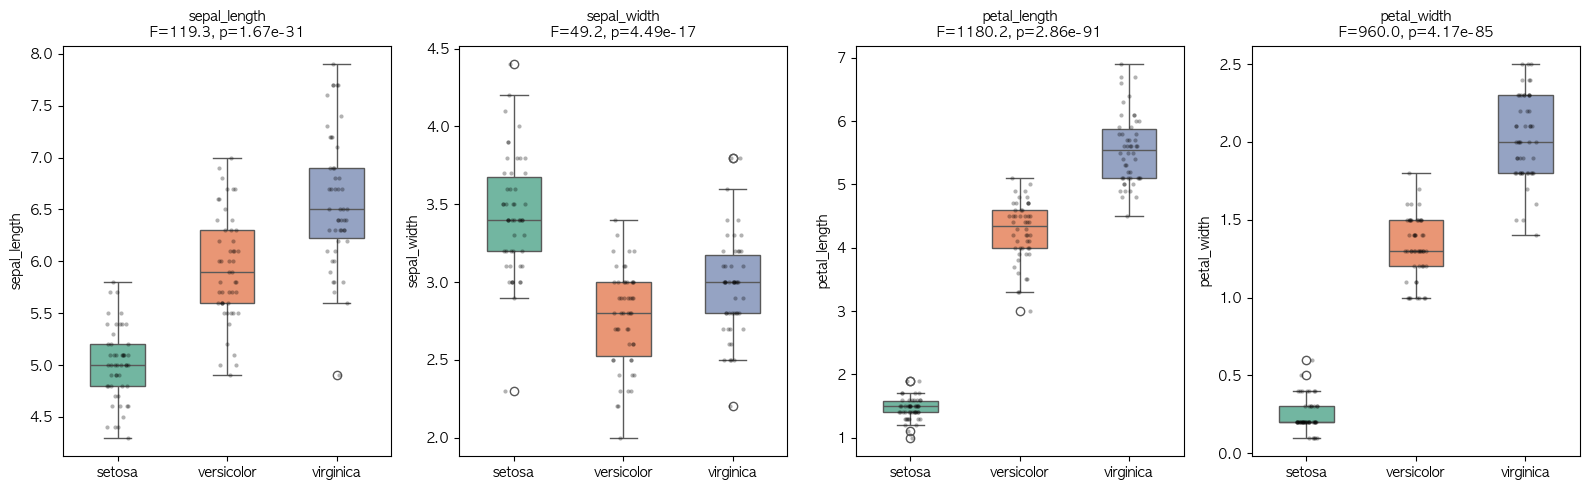

In [32]:
plt.figure(figsize=(16, 5))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, 4, i)
    sns.boxplot(data=df, x='species', y=col, palette='Set2', width=0.5)
    sns.stripplot(data=df, x='species', y=col, color='black', alpha=0.3, size=3)
    species_names = df['species'].unique() # ['setosa', 'versicolor', 'virginica']
    # groups = []
    # for s in species_names:
    #    group_values = df[ df['species'] == s ][col] # 예:df[ df['species'] == 'setosa' ]['sepal_length']
    #    groups.append(group_values)
    groups = [ df[ df['species'] == s ][col] for s in species_names ]
    f_stat, p_val = stats.f_oneway(*groups)
    plt.title(f'{col}\nF={f_stat:.1f}, p={p_val:.2e}', fontsize=10)
    plt.xlabel('')
plt.tight_layout()
plt.show()

## PCA (주성분분석)
- 4개 변수를 2개 주성분으로 차원 축소
- 분산 설명력(explained variance ratio) 확인

In [33]:
# mglearn 라이브러리가 없으면 설치하라.
try:
    import mglearn
except:
    ! pip install mglearn

In [34]:
import mglearn

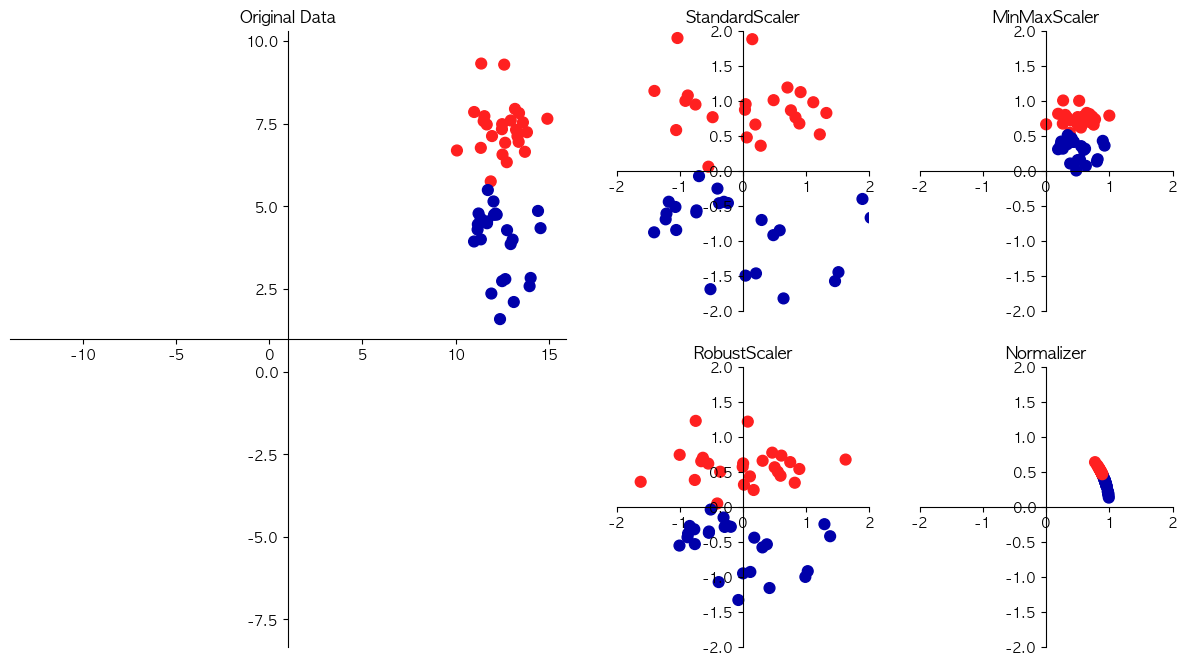

In [35]:
# 표준화(정규화) 그래프
mglearn.plots.plot_scaling()

In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [37]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[numeric_cols])

In [38]:
print( df[numeric_cols].mean().values.round(2) )
print( X_scaled.mean(axis=0).round(2) ) # 평균 0
print( X_scaled.std(axis=0).round(2) )  # 표준편차 1, 표준화 잘 됐다는 뜻

[5.84 3.06 3.76 1.2 ]
[-0. -0. -0. -0.]
[1. 1. 1. 1.]


In [39]:
pca_full = PCA()
pca_full.fit(X_scaled) # PCA 수행 (전체 성분)

print("=== PCA 분산 설명력 ===")
print("주성분\t설명력\t누적 설명력")
# 각 주성분(PC1, PC2...)이 전체 데이터의 정보를 얼마나(몇 %) 가지고 있는지 누적 합계 얻기
cumsum = np.cumsum( pca_full.explained_variance_ratio_ )
for i, (var, cum) in enumerate( zip( pca_full.explained_variance_ratio_, cumsum ) ):
    print(f"PC{i+1}\t{var:.4f}\t{cum:.4f}")

=== PCA 분산 설명력 ===
주성분	설명력	누적 설명력
PC1	0.7296	0.7296
PC2	0.2285	0.9581
PC3	0.0367	0.9948
PC4	0.0052	1.0000


In [40]:
print( pca_full.explained_variance_ratio_ ) # PC1, PC2, PC3, PC4

[0.72962445 0.22850762 0.03668922 0.00517871]


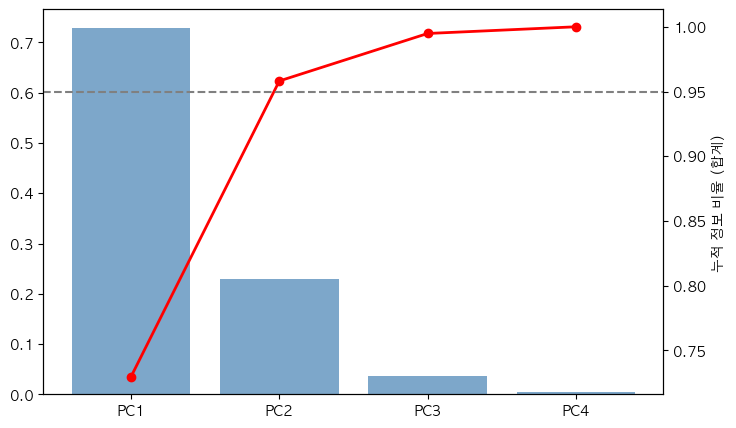

In [41]:
evrs = pca_full.explained_variance_ratio_ # array([0.72962445, 0.22850762, 0.03668922, 0.00517871])
pcs = [ f'PC{i+1}' for i in range( len( evrs ) ) ] # ['PC1', 'PC2', 'PC3', 'PC4']
plt.figure(figsize=(8, 5))
# 막대 그래프 (왼쪽 Y축 기준)
plt.bar(pcs, evrs, color='steelblue', alpha=0.7)
ax2 = plt.twinx() # "지금 그래프 위에 오른쪽 눈금을 하나 더 얹어줘"라는 뜻
# 누적 선 그래프 (오른쪽 Y축 기준)
ax2.plot(pcs, cumsum, 'ro-', linewidth=2)
ax2.set_ylabel('누적 정보 비율 (합계)') # 오른쪽 Y축 이름
ax2.axhline(y=0.95, color='gray', linestyle='--', label='95% 목표선')
plt.show()

In [42]:
pca = PCA(n_components=2) # PCA 2차원 변환
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['species'] = df['species']

evrs = pca.explained_variance_ratio_ # [0.72962445 0.22850762]
evr0 = evrs[0]
evr1 = evrs[1]

print(f"PC1 설명력: {evr0:.4f} ({evr0*100:.1f}%)")
print(f"PC2 설명력: {evr1:.4f} ({evr1*100:.1f}%)")
print(f"누적 설명력: {sum(evrs)*100:.1f}%")

PC1 설명력: 0.7296 (73.0%)
PC2 설명력: 0.2285 (22.9%)
누적 설명력: 95.8%


In [43]:
loading = pd.DataFrame(pca.components_.T,
                        columns=['PC1', 'PC2'],
                        index=numeric_cols)
print("=== 주성분 적재값 (Loading) ===")
print(loading.round(4))
print("해석: 절대값이 클수록 해당 변수가 주성분에 기여하는 비중이 큼")

=== 주성분 적재값 (Loading) ===
                 PC1     PC2
sepal_length  0.5211  0.3774
sepal_width  -0.2693  0.9233
petal_length  0.5804  0.0245
petal_width   0.5649  0.0669
해석: 절대값이 클수록 해당 변수가 주성분에 기여하는 비중이 큼


## 군집분석 (K-Means Clustering)
- 비지도학습: 레이블 없이 자연적인 그룹 탐색
- 엘보우 방법으로 최적 k 결정

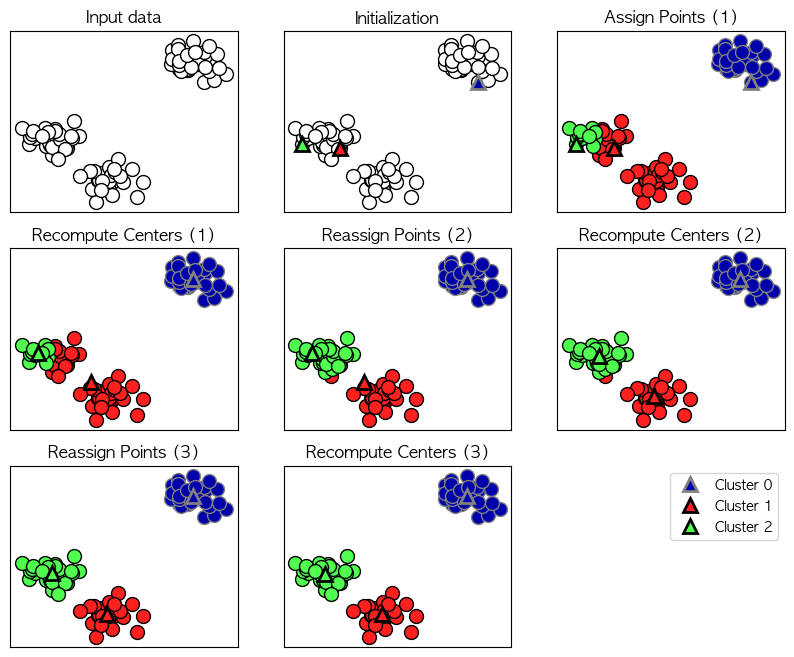

In [44]:
mglearn.plots.plot_kmeans_algorithm()

In [45]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

# Inertia(관성)는 물체가 외부 힘을 받지 않으면 정지 상태나 등속 운동 상태를 계속 유지하려는 성질
inertias = [] # 엘보우 방법 (Elbow Method) : 꺽이는 부분이 답
silhouette_scores = [] # 실루엣 방법 : 가장 큰 값이 답
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init=10 : 서로 다른 랜덤 위치에서 10번 실행해서 가장 좋은 값 선택
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, km.labels_))

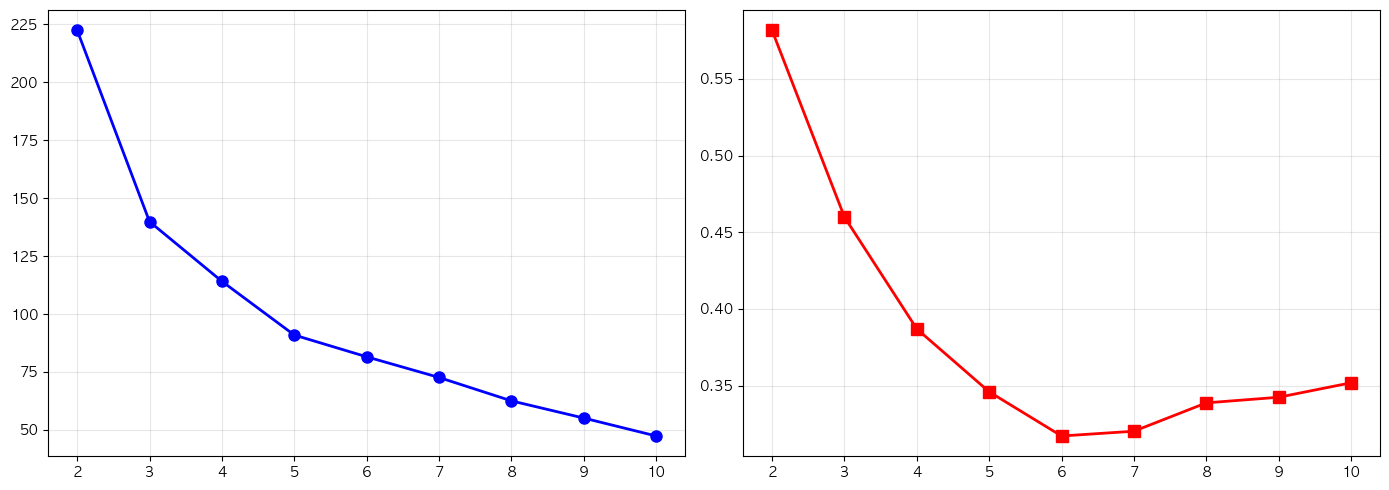

실루엣 점수 최대: k=2, score=0.5818


In [46]:
# 엘보우 플롯 + 실루엣 점수
plt.figure(figsize=(14, 5))
plt.subplot(121)
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xticks(list(K_range))
plt.grid(alpha=0.3)
plt.subplot(122)
plt.plot(K_range, silhouette_scores, 'rs-', linewidth=2, markersize=8)
plt.xticks(list(K_range))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f"실루엣 점수 최대: k={K_range[np.argmax(silhouette_scores)]}, "
      f"score={max(silhouette_scores):.4f}")

In [47]:
# K-Means (k=3) 실행
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print("=== K-Means 군집 결과 (k=3) ===")
print(f"실루엣 점수: {silhouette_score(X_scaled, df['cluster']):.4f}")
print()
print("군집별 데이터 수:")
print(df['cluster'].value_counts().sort_index())

=== K-Means 군집 결과 (k=3) ===
실루엣 점수: 0.4599

군집별 데이터 수:
cluster
0    53
1    50
2    47
Name: count, dtype: int64


In [48]:
# 군집 vs 실제 품종 교차표
print("=== 군집 vs 실제 품종 교차표 ===")
cross_tab = pd.crosstab(df['cluster'], df['species'],
                         margins=True, margins_name='합계')
cross_tab

=== 군집 vs 실제 품종 교차표 ===


species,setosa,versicolor,virginica,합계
cluster,,,,
0,0,39,14,53
1,50,0,0,50
2,0,11,36,47
합계,50,50,50,150


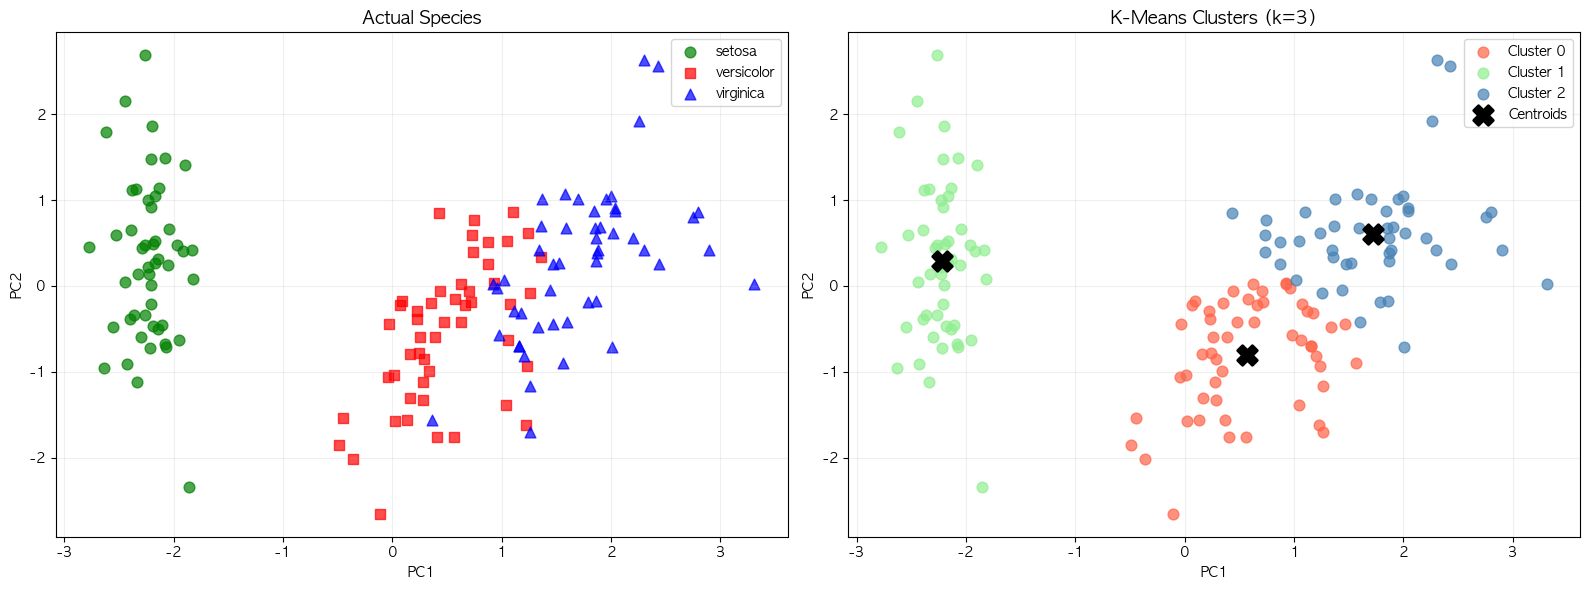

In [49]:
# 군집 시각화 (PCA 공간)
species_list = ['setosa', 'versicolor', 'virginica']
colors = ['green', 'red', 'blue']
markers = ['o', 's', '^']
plt.figure(figsize=(16, 6))
plt.subplot(121) # 왼쪽 그래프: 실제 품종 (Actual Species)
# zip을 사용해 이름, 색상, 모양을 하나씩 짝지어서 반복합니다.
for sp, color, marker in zip(species_list, colors, markers):
    # # 해당 품종인 데이터만 골라내는 '가리개(mask)' 만들기
    mask = df['species'] == sp
    # # PCA 데이터(df_pca)에서 해당 품종의 PC1, PC2 좌표만 점으로 찍기
    plt.scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
                c=color, marker=marker, s=60, alpha=0.7, label=sp)
plt.title('Actual Species', fontsize=13, fontweight='bold')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(alpha=0.2)

plt.subplot(122) # 오른쪽 그래프: K-Means 군집 (Clusters)
cluster_colors = ['tomato', 'lightgreen', 'steelblue']
for cl in range(3):
    # # AI가 분류한 군집 번호(cluster)가 현재 번호와 같은 행만 골라내기
    mask = df['cluster'] == cl
    plt.scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
                c=cluster_colors[cl], s=60, alpha=0.7, label=f'Cluster {cl}')
# [중요] 중심점(Centroids) 표시
# 원래 4차원이었던 군집 중심점 좌표를 PCA 평면(2차원)용 좌표로 변환합니다.
centers_pca = pca.transform(kmeans.cluster_centers_)
# 변환된 중심점을 검정색 'X' 모양으로 크게 그립니다.
plt.scatter(centers_pca[:, 0], centers_pca[:, 1],
            c='black', marker='X', s=200, linewidths=2, label='Centroids')
plt.title('K-Means Clusters (k=3)', fontsize=13, fontweight='bold')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 군집 프로파일링 (Cluster Profiling)
- 각 군집의 특성을 분석하고 해석
- 군집별 평균, 표준편차 비교
- 레이더 차트로 시각화

In [50]:
# 군집별 기술통계
print("=== 군집별 평균 ===")
cluster_profile = df.groupby('cluster')[numeric_cols].mean().round(2)
display(cluster_profile)
print()

print("=== 군집별 표준편차 ===")
cluster_std = df.groupby('cluster')[numeric_cols].std().round(2)
display(cluster_std)

=== 군집별 평균 ===


,sepal_length,sepal_width,petal_length,petal_width
cluster,,,,
0,5.80,2.67,4.37,1.41
1,5.01,3.43,1.46,0.25
2,6.78,3.10,5.51,1.97



=== 군집별 표준편차 ===


,sepal_length,sepal_width,petal_length,petal_width
cluster,,,,
0,0.41,0.25,0.56,0.31
1,0.35,0.38,0.17,0.11
2,0.49,0.26,0.64,0.33


In [51]:
# 전체 평균 대비 군집 특성 (z-score 방식)
overall_mean = df[numeric_cols].mean()
overall_std = df[numeric_cols].std()

# z-score(표준 점수) : 모든 숫자를 "평균으로부터 몇 표준편차만큼 떨어져 있는가?"라는 공통된 단위로 바꿔버리는 것
profile_z = (cluster_profile - overall_mean) / overall_std
print("=== 군집별 프로파일 (전체 평균 대비 z-score) ===")
display(profile_z.round(3))
print()
print("해석: 양수 = 평균보다 높음, 음수 = 평균보다 낮음")

=== 군집별 프로파일 (전체 평균 대비 z-score) ===


,sepal_length,sepal_width,petal_length,petal_width
cluster,,,,
0,-0.052,-0.889,0.347,0.276
1,-1.006,0.855,-1.302,-1.245
2,1.131,0.098,0.992,1.011



해석: 양수 = 평균보다 높음, 음수 = 평균보다 낮음


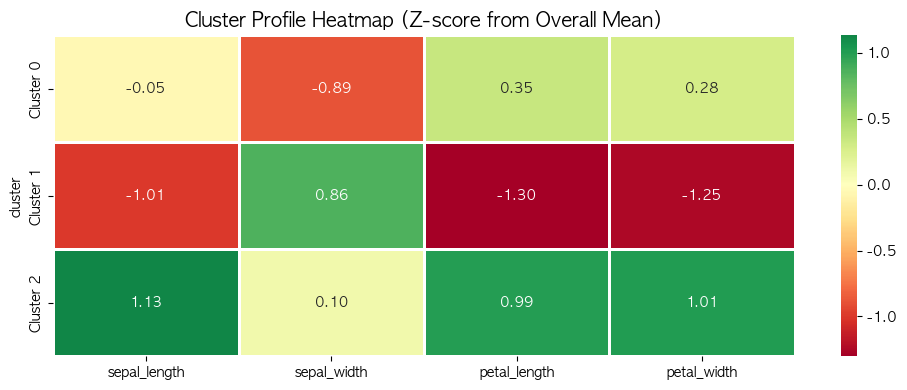

In [52]:
# 프로파일 히트맵
plt.figure(figsize=(10, 4))
sns.heatmap(profile_z, annot=True, cmap='RdYlGn', center=0,
            fmt='.2f', linewidths=1, linecolor='white',
            xticklabels=numeric_cols,
            yticklabels=[f'Cluster {i}' for i in range(3)])
plt.title('Cluster Profile Heatmap (Z-score from Overall Mean)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [53]:
# 최종 프로파일 요약
for cl in range(3):
    # # 이 팀(cluster == cl)에서 가장 많이 등장한 품종 이름(최빈값)을 가져옵니다.
    dominant_species = df[df['cluster'] == cl]['species'].mode()[0]
    # 이 팀에 속한 데이터(붓꽃)가 총 몇 개인지 셉니다.
    n = len(df[df['cluster'] == cl])
    print(f"\n【 Cluster {cl} 】 (n={n}, 주요 품종: {dominant_species})")
    print("-" * 50)
    for col in numeric_cols:
        mean_val = cluster_profile.loc[cl, col] # 이 팀의 평균값
        z_val = profile_z.loc[cl, col]          # 이 팀의 표준 점수(z-score)
        level = "↑ 높음" if z_val > 0.5 else "↓ 낮음" if z_val < -0.5 else "→ 보통"
        print(f"  {col:<15}: {mean_val:>6.2f}  (z={z_val:>6.3f}, {level})")
# 기준선 0.5: 보통 통계적으로 z-score가 0.5보다 크면 "평균보다 확실히 높네", -0.5보다 작으면 "확실히 낮네"라고 해석.
# 그 사이면 "그냥 보통 수준이네"라고 판정


【 Cluster 0 】 (n=53, 주요 품종: versicolor)
--------------------------------------------------
  sepal_length   :   5.80  (z=-0.052, → 보통)
  sepal_width    :   2.67  (z=-0.889, ↓ 낮음)
  petal_length   :   4.37  (z= 0.347, → 보통)
  petal_width    :   1.41  (z= 0.276, → 보통)

【 Cluster 1 】 (n=50, 주요 품종: setosa)
--------------------------------------------------
  sepal_length   :   5.01  (z=-1.006, ↓ 낮음)
  sepal_width    :   3.43  (z= 0.855, ↑ 높음)
  petal_length   :   1.46  (z=-1.302, ↓ 낮음)
  petal_width    :   0.25  (z=-1.245, ↓ 낮음)

【 Cluster 2 】 (n=47, 주요 품종: virginica)
--------------------------------------------------
  sepal_length   :   6.78  (z= 1.131, ↑ 높음)
  sepal_width    :   3.10  (z= 0.098, → 보통)
  petal_length   :   5.51  (z= 0.992, ↑ 높음)
  petal_width    :   1.97  (z= 1.011, ↑ 높음)


In [54]:
# end